(a) I am implementing the time-invariant control policy as a function of the residual between the equilibrium state and current angle. 

For this, I first find nearest closest integer multiple to $2\pi$ as follows 
$$
k = \text{round}\Big(\frac{q_0(t)}{2\pi} \Big)
$$
Then I calculate the residual from the current position as $e(t) = 2k\pi - q_0(t)$. 
Finally, the control policy $$\pi(t) = - e(t) - \dot e(t) - mgl\sin(q_0(t))$$
where I add the last term to remove the non-linearity in the equation 1.12 and make it a linear differential equation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Numerical parameters.
m = 1 # mass
g = 10 # gravity
l = .1 # length
h = .0001 # discretization step
T = 2 # time horizon

In [3]:
# Control policy: given the state, returns the control input.

def pi(x):
    k = np.round(x[0]/2/np.pi, 0) # Find the closest integer multiple
    e =  x[0] - k*2*np.pi
    edot = x[1]
    u = e + edot + m * g * l * np.sin(x[0]) # PD controller
    return -u

In [4]:
# Closed-loop dynamics.
def f(x):
    return np.array([
        x[1], # angular velocity
        (m * g * l * np.sin(x[0]) + pi(x)) / (m * l ** 2)]) # angular acceleration

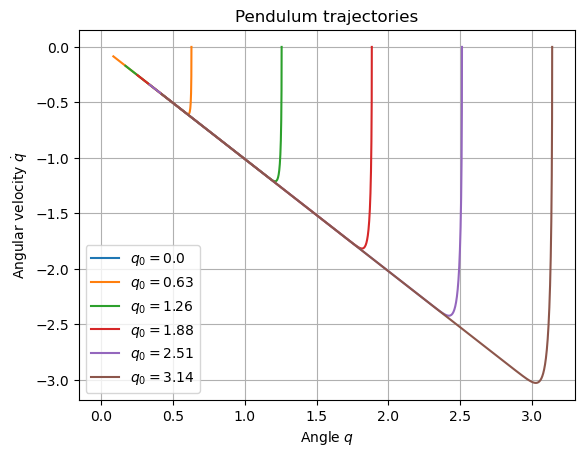

In [5]:
# Plot trajectories for different initial angles. Uses explicit Euler for the
# simulation.
plt.figure()
K = int(T / h) # time steps in discrete-time simulation
traj = np.zeros((K, 2)) # matrix of states
for q0 in np.pi * np.arange(6) / 5: # loop through multiple initial angles
    traj[0] = [q0, 0] # set initial state
    for k in range(K - 1):
        traj[k + 1] = traj[k] + h * f(traj[k]) # explicit Euler
    plt.plot(
        traj[:,0], # angle
        traj[:,1], # angular velocity
        label=fr'$q_0={np.round(q0, 2)}$')

# Plot options.
plt.xlabel(r'Angle $q$')
plt.ylabel(r'Angular velocity $\dot q$')
plt.title('Pendulum trajectories')
plt.legend()
plt.grid()